Explain code:

https://chatgpt.com/c/68e0378d-3844-8321-abe7-c7960857af21

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

1. N = 100

This sets the number of data points to 100.

2. X = np.random.random(N) * 6 - 3

np.random.random(N) → generates N random numbers between 0 and 1.

Multiplying by 6 → rescales them to the range 0 to 6.

Subtracting 3 → shifts the range to -3 to +3.

So, X is an array of 100 random values uniformly distributed between -3 and +3.

3. y = 0.5 * X - 1 + np.random.randn(N) * 0.5

This creates the target variable y:

The underlying relationship is y = 0.5 * X - 1.

This is a straight line with slope 0.5 and intercept -1.

np.random.randn(N) generates Gaussian noise (mean 0, std 1).

Multiplying by 0.5 → noise is scaled, so the points don’t sit exactly on the line

In [3]:
# create a linear regression data set
N = 100
X =np.random.random(N)* 6-3
y = 0.5 * X - 1 + np.random.randn(N)* 0.5

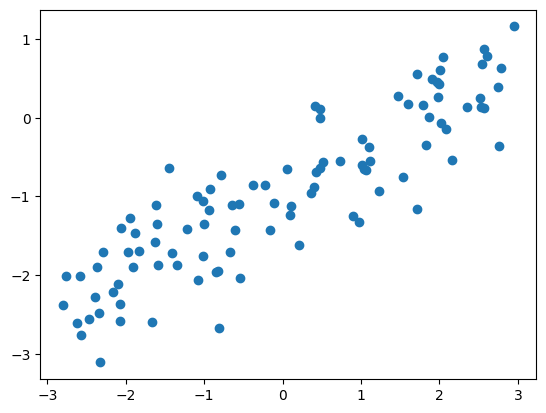

In [4]:
plt.scatter(X,y)

In [5]:
# build model
i = Input(shape=(1,))
x = Dense(1)(i)

model = Model(i, x)

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
  loss='mse', # mean square error (mse)
  # optimizer='adam',
  optimizer=Adam(learning_rate=0.1),
  metrics=['mae'] # mean absolute error
)

In [10]:
r = model.fit(
    X.reshape(-1,1),y,
    epochs = 200,
    batch_size = 32,
    )

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1923 - mae: 2.6126 
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.6169 - mae: 2.0624 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.9048 - mae: 1.4708 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2681 - mae: 0.9420 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5146 - mae: 0.5787
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3220 - mae: 0.4737  
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3281 - mae: 0.4581 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4005 - mae: 0.5151 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4330 - mae: 0.5312 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4379 - mae: 0.5350 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3431 - mae: 0.4650
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2466 - mae: 0.3924 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/st

X.reshape(-1,1)

Your X array was originally 1-dimensional (shape = (100,)).

Keras expects 2D input: (samples, features).

reshape(-1,1) converts it to (100,1), meaning 100 samples, each with 1 feature.

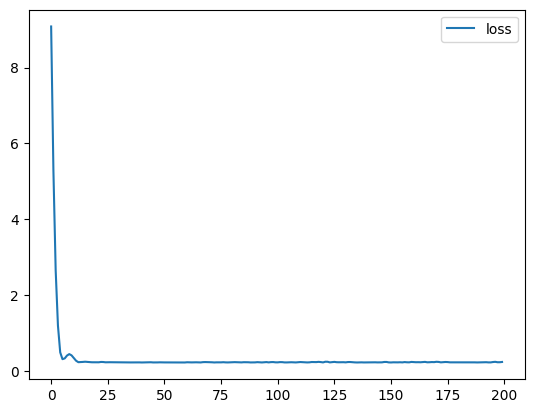

In [11]:
# Plot loss per iteration
plt.plot(r.history['loss'], label='loss')
plt.legend();

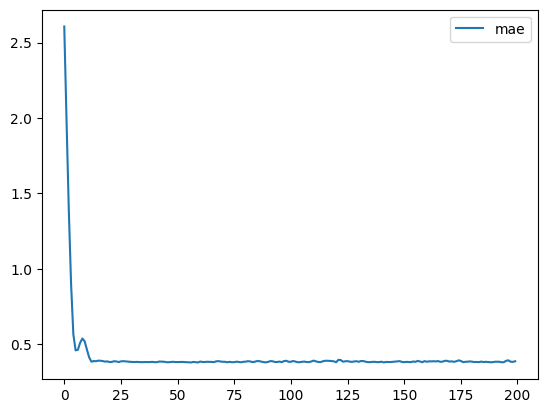

In [12]:
# Plot mae per iteration
plt.plot(r.history['mae'], label='mae')
plt.legend();

In [13]:
# Make predictions
Xtest = np.linspace(-3, 3, 20).reshape(-1, 1)
ptest = model.predict(Xtest)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


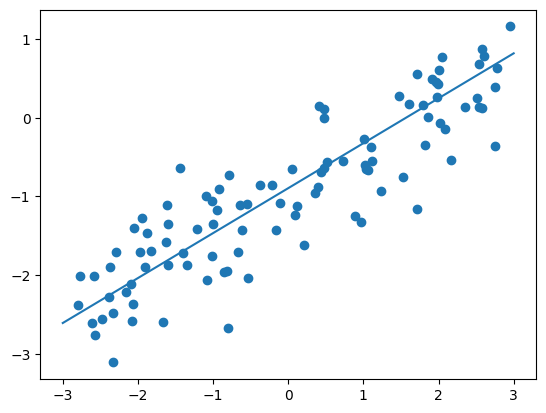

In [14]:
plt.scatter(X, y)
plt.plot(Xtest, ptest);

In [15]:
# check the learned parameters
model.layers

[<InputLayer name=input_layer, built=True>, <Dense name=dense, built=True>]

In [16]:
model.layers[1].get_weights()

[array([[0.5715684]], dtype=float32), array([-0.8953213], dtype=float32)]